# Plots

Visualizations across all models (baselines, CNN, Attention CNN).
Requires results saved by the individual training notebooks.

## 0 — Setup

In [1]:
import sys, os
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install -q rasterio geopandas h5py huggingface_hub scikit-learn
    if not os.path.isdir('downscaling'):
        !git clone -q https://github.com/fresleven/downscaling.git
    %cd downscaling
    sys.path.insert(0, '.')
else:
    sys.path.insert(0, os.path.abspath('../..'))


## 1 — Load results

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

RESULTS  = 'results'
DATA_ROOT = 'data'

# ── test scenes (full GT from baselines notebook) ──
scenes       = np.load(f'{RESULTS}/test_scenes.npz', allow_pickle=True)
test_hr      = scenes['hr']          # (N, 112, 87)  full GT, NaN = cloud
test_lr      = scenes['lr']          # (N,  28, 22)
test_mask    = scenes['mask']        # test-split spatial mask
test_dmask   = scenes['data_mask']   # cloud-free mask (all pixels)
test_dates   = scenes['dates'].tolist()

# ── baselines ──
bl       = np.load(f'{RESULTS}/baselines_preds.npz')
bi_test  = bl['bi_test']
bc_test  = bl['bc_test']
la_test  = bl['la_test']

# ── CNN ──
cnn_d    = np.load(f'{RESULTS}/cnn_preds.npz',    allow_pickle=True)
cnn_test = cnn_d['test_pred']         # (N, 112, 87)
cnn_h    = np.load(f'{RESULTS}/cnn_history.npz')
cnn_ep   = cnn_h['epochs']
cnn_rmse = cnn_h['val_rmse_mean']
cnn_std  = cnn_h['val_rmse_std']
print(cnn_test)

# ── Attention CNN ──
attn_d    = np.load(f'{RESULTS}/attn_preds.npz',   allow_pickle=True)
attn_test = attn_d['test_pred']
attn_h    = np.load(f'{RESULTS}/attn_history.npz')
attn_ep   = attn_h['epochs']
attn_rmse = attn_h['val_rmse_mean']
attn_std  = attn_h['val_rmse_std']

print(f'Loaded {len(test_dates)} test dates.')
print(f'CNN history: {len(cnn_ep)} epochs,  Attn history: {len(attn_ep)} epochs')


[[[       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  ...
  [       nan        nan        nan ... -6.100523  -6.156589  -5.9664   ]
  [       nan        nan        nan ... -5.1900024 -5.13977   -4.864062 ]
  [       nan        nan        nan ... -4.2932816 -4.0947704 -4.1160274]]

 [[       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  [       nan        nan        nan ...        nan        nan        nan]
  ...
  [       nan        nan        nan ... -4.2649307 -4.0776176 -4.2502723]
  [       nan        nan        nan ... -3.2396808 -3.1402147 -3.2136605]
  [       nan        nan        nan ... -2.3744206 -2.013608  -2.3556843]]

 [[       nan        nan        nan ...        nan        nan        nan]
  [       nan        n

## 1.5 — Load models & generate full-scene CNN predictions

The saved `cnn_preds.npz` / `attn_preds.npz` only contain predictions for the
8 test spatial blocks (NaN elsewhere) because `reconstruct_scene` in the training
notebooks iterates over `ds.split_blocks`.  Here we reload the saved weights and
run inference on **all 30 spatial blocks** so every cloud-free pixel has a
prediction.

In [3]:
from model.dataset import DownscalingDataset
from model.cnn import GuidedCNN
from model.attention_cnn import AttentionAugmentedCNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Dataset (metadata only, no download) ─────────────────────────────────
test_ds   = DownscalingDataset(root=DATA_ROOT, split='test', download=False)
n_classes = len(test_ds.lulc_classes)

# Map date string → index in test_ds.dates (for alignment with test_scenes.npz)
ds_date_to_idx = {d.strftime('%Y-%m-%d'): i for i, (d, _) in enumerate(test_ds.dates)}

# ── CNN: cov = NDVI + DEM + LULC_onehot + loc ────────────────────────────
cnn_model = GuidedCNN(
    cov_channels=1 + 1 + n_classes + 2,
    base_channels=64, n_lr_blocks=4, n_hr_blocks=6, dropout=0.1,
).to(device)
cnn_model.load_state_dict(torch.load('cnn_baseline.pt', map_location=device))
cnn_model.eval()

# ── Attention CNN: cov = NDVI + DEM + LULC_onehot (no loc) ───────────────
attn_model = AttentionAugmentedCNN(
    cov_channels=1 + 1 + n_classes,
    base_channels=64, n_lr_blocks=4, n_hr_blocks=6, dropout=0.1,
).to(device)
attn_model.load_state_dict(torch.load('attention_cnn.pt', map_location=device))
attn_model.eval()

def _make_cov_cnn(b):
    return torch.cat([b['ndvi'], b['dem'], b['lulc_onehot'], b['loc']], dim=1)

def _make_cov_attn(b):
    return torch.cat([b['ndvi'], b['dem'], b['lulc_onehot']], dim=1)


def reconstruct_full_scene(model, ds, date_idx, make_cov_fn, all_blocks, device):
    """Predict over every spatial block for date_idx in ds.dates."""
    H, W = ds.hr_shape
    pred = np.full((H, W), np.nan, dtype=np.float32)

    orig_split = ds.split_blocks
    ds.split_blocks = all_blocks          # temporarily expose all blocks to __getitem__
    model.eval()
    with torch.no_grad():
        for blk_idx, block_id in enumerate(all_blocks):
            sample = ds[date_idx * len(all_blocks) + blk_idx]
            r0, r1, c0, c1 = ds.block_bboxes[block_id]
            bH, bW = r1 - r0, c1 - c0
            b = {k: v.unsqueeze(0).to(device) if torch.is_tensor(v) else v
                 for k, v in sample.items()}
            pr = model(b['lr_lst'], make_cov_fn(b), b['lr_mask'],
                       b['lr_bicubic']).squeeze().cpu().numpy()
            pred[r0:r1, c0:c1] = pr[:bH, :bW]
    ds.split_blocks = orig_split
    return pred


all_blocks = sorted(test_ds.block_bboxes.keys())   # all 30 blocks
N = len(test_dates)
H, W = test_ds.hr_shape

cnn_test_full  = np.full((N, H, W), np.nan, dtype=np.float32)
attn_test_full = np.full((N, H, W), np.nan, dtype=np.float32)

for i, date_str in enumerate(test_dates):
    date_idx = ds_date_to_idx[date_str]
    cnn_test_full[i]  = reconstruct_full_scene(
        cnn_model,  test_ds, date_idx, _make_cov_cnn,  all_blocks, device)
    attn_test_full[i] = reconstruct_full_scene(
        attn_model, test_ds, date_idx, _make_cov_attn, all_blocks, device)
    if i % 50 == 0:
        print(f'  {i}/{N}  ({date_str})')

# Replace the test-only predictions with full-scene versions
cnn_test  = cnn_test_full
attn_test = attn_test_full

# Save so stations.ipynb (and future runs) can load without re-generating
import os; os.makedirs(RESULTS, exist_ok=True)
np.savez_compressed(f'{RESULTS}/cnn_preds_full.npz',  test_pred=cnn_test_full,
                    dates=np.array(test_dates))
np.savez_compressed(f'{RESULTS}/attn_preds_full.npz', test_pred=attn_test_full,
                    dates=np.array(test_dates))
print('Full-scene CNN and Attention CNN predictions ready and saved.')


  0/308  (2023-01-02)
  50/308  (2023-02-28)
  100/308  (2023-04-30)
  150/308  (2023-07-01)
  200/308  (2023-08-21)
  250/308  (2023-10-16)
  300/308  (2023-12-22)
Full-scene CNN and Attention CNN predictions ready and saved.


## 2 — Val RMSE vs epoch (with ±1 std band)

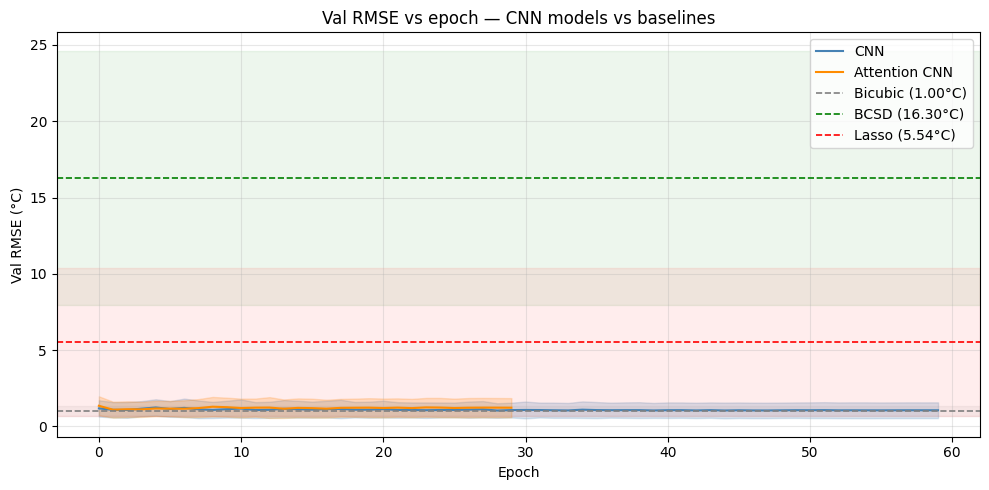

In [4]:
# ── Per-scene RMSE helper ──────────────────────────────────────────────────
def scene_rmse(pred, hr, mask):
    rmses = []
    for i in range(len(pred)):
        m = mask[i]
        p = pred[i][m]; t = hr[i][m]
        valid = np.isfinite(p) & np.isfinite(t)
        if valid.sum() == 0:
            continue
        rmses.append(float(np.sqrt(np.mean((p[valid] - t[valid]) ** 2))))
    return np.array(rmses)

bi_rmses = scene_rmse(bi_test, test_hr, test_dmask)
bc_rmses = scene_rmse(bc_test, test_hr, test_dmask)
la_rmses = scene_rmse(la_test, test_hr, test_dmask)

# ── RMSE vs epoch (val) with ±1 std band ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cnn_ep,  cnn_rmse,  color='steelblue', label='CNN')
ax.fill_between(cnn_ep, cnn_rmse - cnn_std, cnn_rmse + cnn_std,
                color='steelblue', alpha=0.20)

ax.plot(attn_ep, attn_rmse, color='darkorange', label='Attention CNN')
ax.fill_between(attn_ep, attn_rmse - attn_std, attn_rmse + attn_std,
                color='darkorange', alpha=0.20)

# Baselines: horizontal lines (test RMSE mean ± std as shaded band)
for label, rmses, color in [
        ('Bicubic', bi_rmses, 'gray'),
        ('BCSD',    bc_rmses, 'green'),
        ('Lasso',   la_rmses, 'red')]:
    mu, sigma = rmses.mean(), rmses.std()
    ax.axhline(mu, linestyle='--', color=color, linewidth=1.2, label=f'{label} ({mu:.2f}°C)')
    ax.axhspan(mu - sigma, mu + sigma, color=color, alpha=0.07)

ax.set_xlabel('Epoch')
ax.set_ylabel('Val RMSE (°C)')
ax.set_title('Val RMSE vs epoch — CNN models vs baselines')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3 — All-model predictions at scene i=30

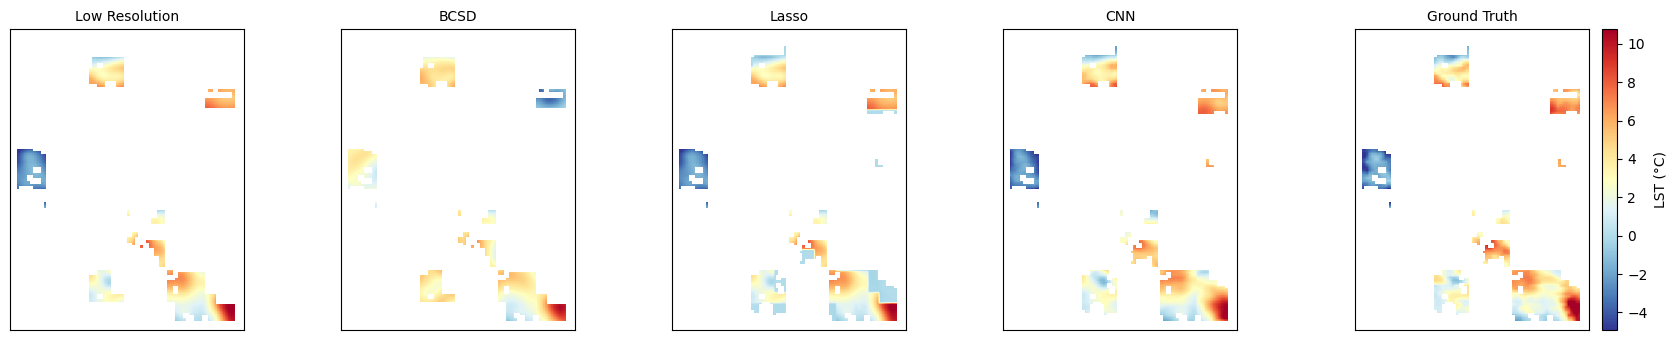

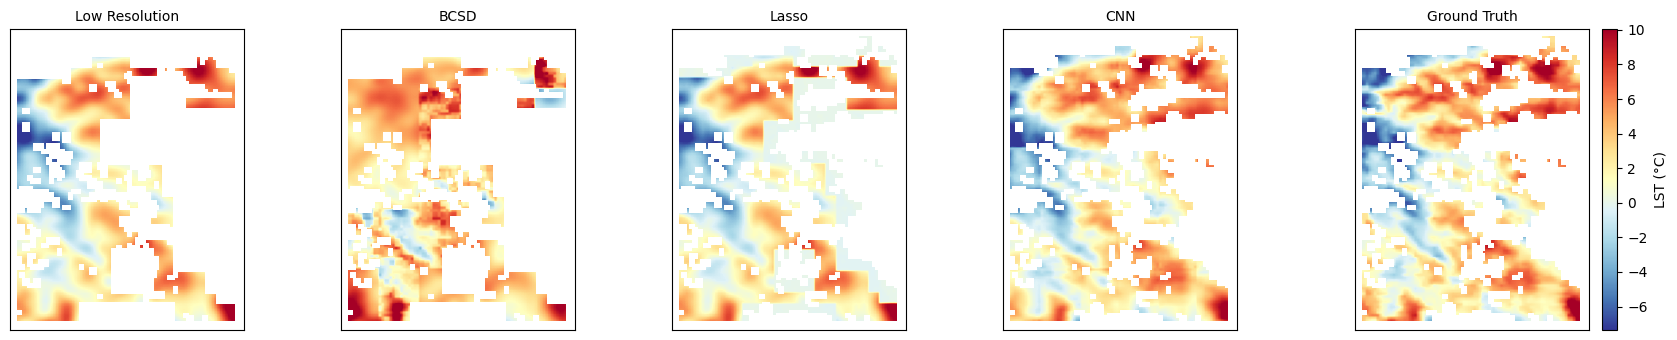

In [10]:
# ── All-model predictions at scene i=30 ──────────────────────────────────
I = 30 # 30 and 200 are good examples
date_str = test_dates[I]

H, W = test_hr.shape[1], test_hr.shape[2]
lr_t  = torch.from_numpy(test_lr[I][None, None]).float()
bi_up = F.interpolate(lr_t, size=(H, W), mode='bicubic', align_corners=False)[0, 0].numpy()

def plot_all_models(spatial_mask, title_suffix):
    gt   = np.where(spatial_mask, test_hr[I], np.nan)
    preds = [
        ('Low Resolution',  np.where(spatial_mask, bi_up,         np.nan)),
        ('BCSD',          np.where(spatial_mask, bc_test[I],    np.nan)),
        ('Lasso',         np.where(spatial_mask, la_test[I],    np.nan)),
        ('CNN',           np.where(spatial_mask, cnn_test[I],   np.nan)),
        # ('Attention CNN', np.where(spatial_mask, attn_test[I],  np.nan)),
        ('Ground Truth', gt),
    ]
    valid_gt = np.isfinite(gt)
    vmin = float(np.nanpercentile(gt[valid_gt], 1))
    vmax = float(np.nanpercentile(gt[valid_gt], 99))

    fig, axes = plt.subplots(1, len(preds), figsize=(3.5 * len(preds), 3.5))
    for ax, (title, img) in zip(axes, preds):
        im = ax.imshow(img, cmap='RdYlBu_r', vmin=vmin, vmax=vmax)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label='LST (°C)')
    # plt.suptitle(f'All models — test scene {I}: {date_str}\n({title_suffix})', fontsize=11, y=1.04)
    plt.tight_layout()
    plt.savefig(f'all_models_{title_suffix}.pdf', bbox_inches='tight')
    plt.show()

plot_all_models(test_mask[I],  'test blocks only')
plot_all_models(test_dmask[I], 'all available blocks')


## 4 — CNN & Attention CNN detail panels (LR | Pred | Error | GT)

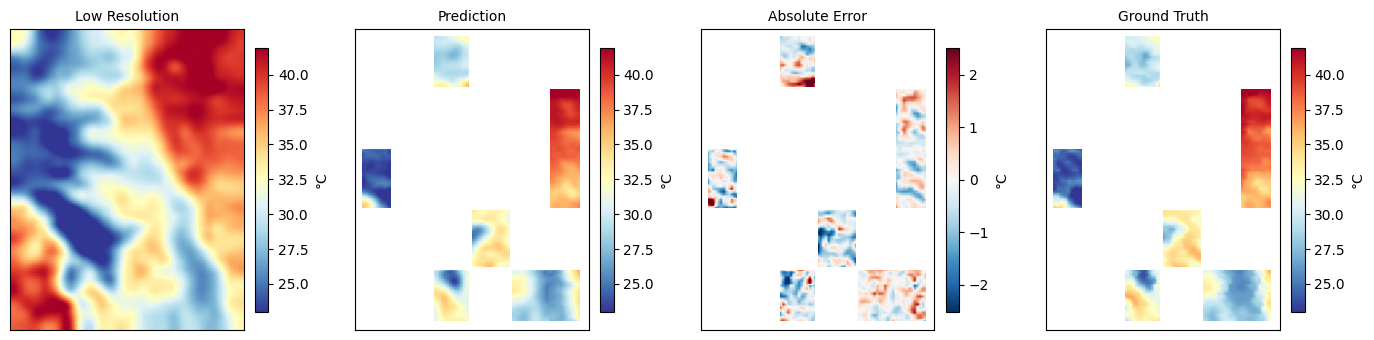

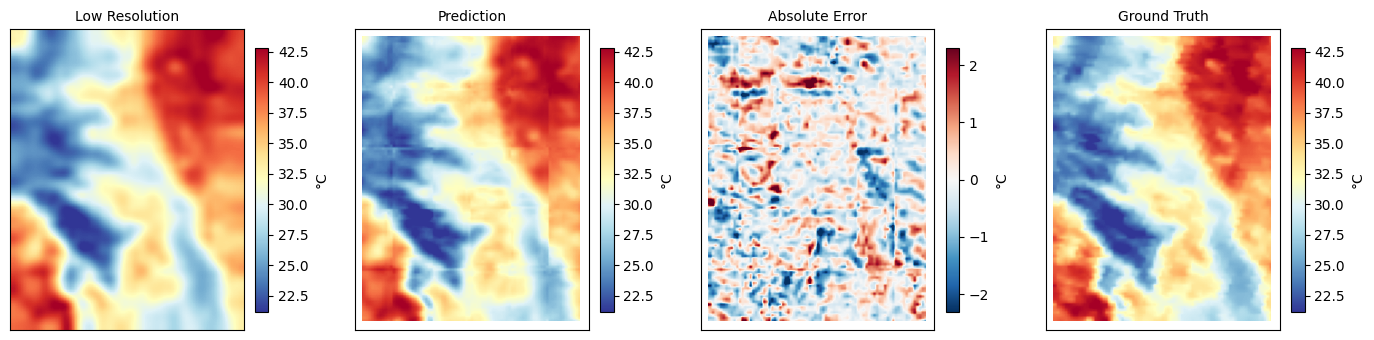

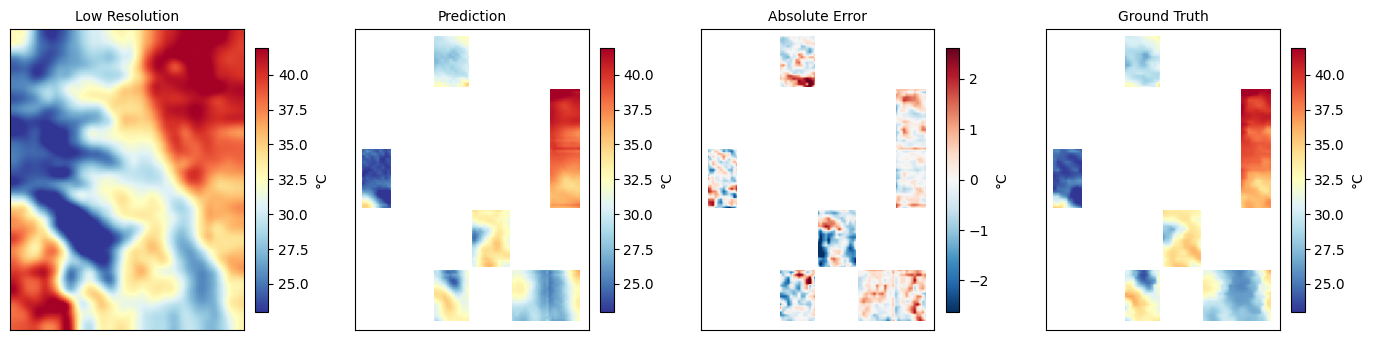

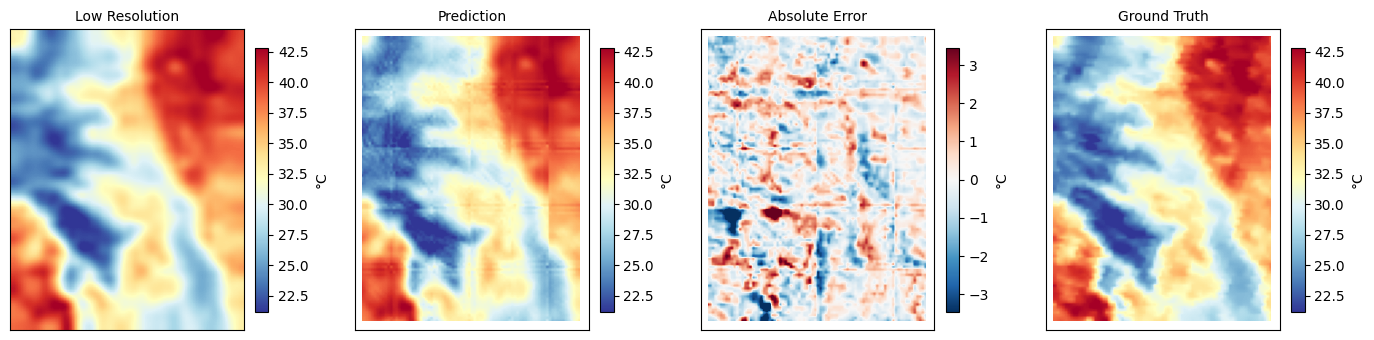

In [6]:
# ── CNN detail: LR | Prediction | Error | GT ──────────────────────────────
def detail_panel(name, pred_arr, hr, lr_up, i, spatial_mask, mask_label):
    gt   = np.where(spatial_mask, hr[i], np.nan)
    pred = np.where(spatial_mask, pred_arr[i], np.nan)
    err  = pred - gt

    valid_gt = np.isfinite(gt)
    vmin = float(np.nanpercentile(gt[valid_gt], 1))
    vmax = float(np.nanpercentile(gt[valid_gt], 99))
    e_abs = float(np.nanpercentile(np.abs(err[np.isfinite(err)]), 99))

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    panels = [
        (lr_up, 'Low Resolution',    'RdYlBu_r', vmin,   vmax),
        (pred,  'Prediction',      'RdYlBu_r', vmin,   vmax),
        (err,   'Absolute Error', 'RdBu_r',  -e_abs,  e_abs),
        (gt,    'Ground Truth',   'RdYlBu_r', vmin,   vmax),
    ]
    for ax, (img, title, cmap, lo, hi) in zip(axes, panels):
        im = ax.imshow(img, cmap=cmap, vmin=lo, vmax=hi)
        ax.set_title(title, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='°C')
    # plt.suptitle(f'{name} — test scene {I}: {date_str}\n({mask_label})', fontsize=11, y=1.04)
    plt.tight_layout()
    plt.savefig(f'detail_panel_{name}.pdf', bbox_inches='tight')
    plt.show()

for model_name, pred_arr in [('CNN', cnn_test), ('Attention CNN', attn_test)]:
    detail_panel(model_name, pred_arr, test_hr, bi_up, I, test_mask[I],  'test blocks only')
    detail_panel(model_name, pred_arr, test_hr, bi_up, I, test_dmask[I], 'all available blocks')


## 5 — RMSE vs elevation band (CNN vs Attention CNN)

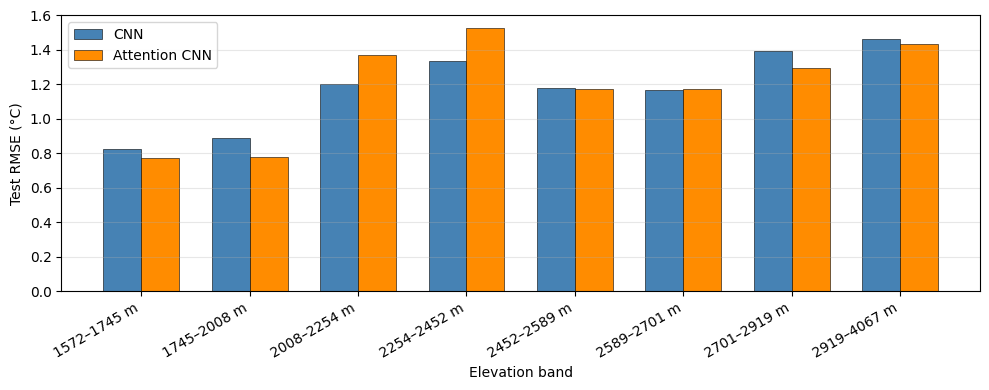

In [7]:
# ── RMSE vs elevation — CNN vs Attention CNN ──────────────────────────────
# test_ds.dem_hr is the 1km DEM over the full scene (112×87)
dem = test_ds.dem_hr   # (112, 87)

elev_all, e2_cnn, e2_attn = [], [], []

for i in range(len(test_dates)):
    # restrict to test-block pixels with valid GT and valid prediction
    m = test_mask[i] & np.isfinite(cnn_test[i]) & np.isfinite(attn_test[i]) & np.isfinite(test_hr[i])
    if not m.any():
        continue
    elev_all.append(dem[m])
    e2_cnn.append( (cnn_test[i][m]  - test_hr[i][m]) ** 2)
    e2_attn.append((attn_test[i][m] - test_hr[i][m]) ** 2)

elev  = np.concatenate(elev_all)
ec    = np.concatenate(e2_cnn)
ea    = np.concatenate(e2_attn)

n_bins = 8
edges = np.percentile(elev, np.linspace(0, 100, n_bins + 1))
labels, cnn_rmse_bins, attn_rmse_bins = [], [], []
for j in range(n_bins):
    sel = (elev >= edges[j]) & (elev <= edges[j + 1])
    if sel.sum() == 0:
        continue
    labels.append(f'{edges[j]:.0f}–{edges[j+1]:.0f} m')
    cnn_rmse_bins.append(float(np.sqrt(ec[sel].mean())))
    attn_rmse_bins.append(float(np.sqrt(ea[sel].mean())))

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, cnn_rmse_bins,  w, label='CNN',          color='steelblue',  edgecolor='black', linewidth=0.4)
ax.bar(x + w/2, attn_rmse_bins, w, label='Attention CNN', color='darkorange', edgecolor='black', linewidth=0.4)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_xlabel('Elevation band')
ax.set_ylabel('Test RMSE (°C)')
# ax.set_title('RMSE vs elevation band — CNN vs Attention CNN (test blocks)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'rmse_vs_elevation.pdf', bbox_inches='tight')
plt.show()


## 6 — Cascaded 4 km → 1 km → 250 m prediction (Attention CNN)\n\nThe 4km→1km Attention CNN output is fed as the LR input to a second model pass\n(same architecture, same weights) that predicts at 250m using finer\nNDVI/DEM/LULC covariates. All three panels are shown at 250m resolution\nso the spatial detail added at each step is visible side-by-side.

250m dataset: 297 test dates  |  HR shape (446, 347)  |  LR shape (112, 87)


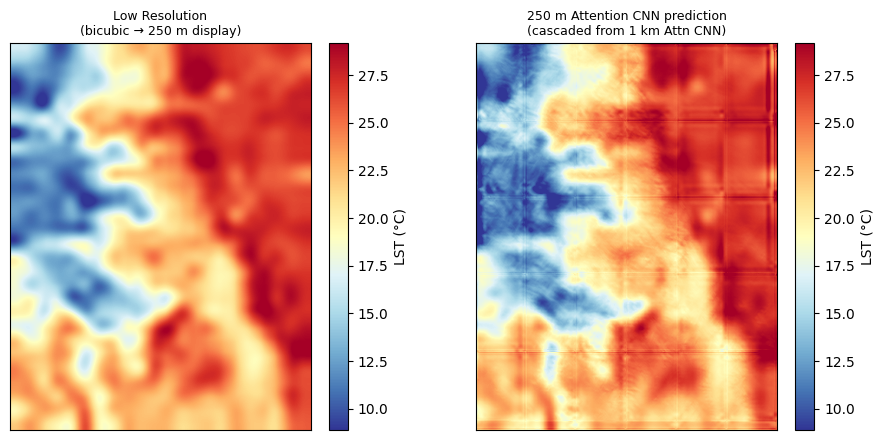

In [8]:
from model.dataset import _pad2d

# ── Load 250m dataset; align LULC classes to training set ─────────────────
ds_250      = DownscalingDataset(root=DATA_ROOT, split='test', lr_res='1km', hr_res='250m', download=False)
ds_250.lulc_classes = test_ds.lulc_classes   # same 15 classes the model was trained with
all_blocks_250      = sorted(ds_250.block_bboxes.keys())
d250_to_idx = {d.strftime('%Y-%m-%d'): i for i, (d, _) in enumerate(ds_250.dates)}

print(f'250m dataset: {len(ds_250.dates)} test dates  |  HR shape {ds_250.hr_shape}  |  LR shape {ds_250.lr_shape}')


def predict_250m_cascaded(pred_1km, ds, model, make_cov_fn, date_idx, all_blocks, device):
    """Use a 1km model prediction as LR input → 250m prediction.

    pred_1km is a (112, 87) array — the full-scene output of the 4km→1km model.
    Its blocks are extracted as LR inputs, bicubic-upsampled to 250m block size,
    then fed to the model together with 250m covariates loaded from ds.
    """
    H, W = ds.hr_shape
    pred = np.full((H, W), np.nan, dtype=np.float32)

    orig_split = ds.split_blocks
    ds.split_blocks = all_blocks
    model.eval()
    with torch.no_grad():
        for blk_idx, block_id in enumerate(all_blocks):
            sample = ds[date_idx * len(all_blocks) + blk_idx]
            r0, r1, c0, c1 = ds.block_bboxes[block_id]
            bH, bW = r1 - r0, c1 - c0
            lr0, lr1, lc0, lc1 = ds.lr_block_bboxes[block_id]

            # Extract Attention CNN 1km prediction at LR (1km) pixels for this block
            lr_block    = pred_1km[lr0:lr1, lc0:lc1].copy()
            lr_valid    = np.isfinite(lr_block)
            lr_fill     = float(np.nanmean(lr_block)) if lr_valid.any() else 0.0
            lr_filled   = np.where(lr_valid, lr_block, lr_fill)
            lr_mask_arr = lr_valid.astype(np.float32)

            # Bicubic baseline: Attention CNN 1km block → 250m HR block size
            lr_t    = torch.from_numpy(lr_filled[None, None]).float()
            bicubic = F.interpolate(lr_t, size=(bH, bW), mode='bicubic',
                                    align_corners=False).squeeze().numpy()

            b = {k: v.unsqueeze(0).to(device) if torch.is_tensor(v) else v
                 for k, v in sample.items()}
            # Override LR inputs with cascaded values; HR covariates stay from ds
            b['lr_lst']     = torch.from_numpy(
                _pad2d(lr_filled,    ds.lr_block_h, ds.lr_block_w)
            )[None, None].float().to(device)
            b['lr_mask']    = torch.from_numpy(
                _pad2d(lr_mask_arr,  ds.lr_block_h, ds.lr_block_w)
            )[None, None].float().to(device)
            b['lr_bicubic'] = torch.from_numpy(
                _pad2d(bicubic,      ds.block_h,    ds.block_w)
            )[None, None].float().to(device)

            pr = model(b['lr_lst'], make_cov_fn(b), b['lr_mask'],
                       b['lr_bicubic']).squeeze().cpu().numpy()
            pred[r0:r1, c0:c1] = pr[:bH, :bW]
    ds.split_blocks = orig_split
    return pred


# ── Scene selection ───────────────────────────────────────────────────────
I        = 255
date_str = test_dates[I]
date_idx_250 = d250_to_idx.get(date_str)
if date_idx_250 is None:
    date_idx_250 = 0
    date_str = ds_250.dates[0][0].strftime('%Y-%m-%d')
    print(f'Note: scene {I} not in 250m set; using {date_str}')

pred_250 = predict_250m_cascaded(
    attn_test[I], ds_250, attn_model, _make_cov_attn, date_idx_250, all_blocks_250, device
)

# ── Upsample 4km and 1km to 250m resolution for side-by-side display ─────
H_250, W_250 = ds_250.hr_shape

lr_at_250 = F.interpolate(
    torch.from_numpy(test_lr[I][None, None]).float(),
    size=(H_250, W_250), mode='bicubic', align_corners=False
)[0, 0].numpy()

attn_1km_filled = np.where(np.isfinite(attn_test[I]), attn_test[I],
                            float(np.nanmean(attn_test[I])))
attn_at_250 = F.interpolate(
    torch.from_numpy(attn_1km_filled[None, None]).float(),
    size=(H_250, W_250), mode='bilinear', align_corners=False
)[0, 0].numpy()

valid = np.isfinite(pred_250)
vmin  = float(np.nanpercentile(pred_250[valid], 1))
vmax  = float(np.nanpercentile(pred_250[valid], 99))

panels = [
    (lr_at_250,   'Low Resolution',                       '(bicubic → 250 m display)'),
    # (attn_at_250, '1 km Attention CNN prediction',  '(bilinear → 250 m display)'),
    (pred_250,    '250 m Attention CNN prediction', '(cascaded from 1 km Attn CNN)'),
]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (img, title, subtitle) in zip(axes, panels):
    im = ax.imshow(img, cmap='RdYlBu_r', vmin=vmin, vmax=vmax)
    ax.set_title(f'{title}\n{subtitle}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='LST (°C)')
plt.tight_layout()
plt.savefig(f'cascaded_250m.pdf', bbox_inches='tight')
plt.show()
